In [1]:
!pip install scipy
!pip install statsmodels

# Problem 3: Budget Epicycle

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [3]:
metadata = pd.read_csv('IMDb movies.csv')
ratings = pd.read_csv('IMDb ratings.csv')
df = pd.concat([metadata, ratings], axis=1)

mask = df.columns.duplicated()
df = df.loc[:, ~mask]

/var/folders/2b/gxmh627x4vvgpqmv_3dzvbq80000gn/T/ipykernel_77442/73648191.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv('IMDb movies.csv')


In [4]:
df['worlwide_gross_income'] = df['worlwide_gross_income'].str.replace(r'\D', '', regex=True)
df['budget'] = df['budget'].str.replace(r'\D', '', regex=True)
# convert into numeric values
df['worlwide_gross_income'] = pd.to_numeric(df['worlwide_gross_income'])
df['budget'] = pd.to_numeric(df['budget'])

In [5]:
genre = df['genre'].str.split(',').explode().str.strip().unique()
# df = df[df['genre'].str.contains(genreStrings, regex=True)]
df['isDrama'] = df['genre'].str.contains('Drama')
df['isAction'] = df['genre'].str.contains('Action')
df = df.dropna(subset=['worlwide_gross_income', 'budget'])

for g, col in [('drama','isDrama'), ('action','isAction')]:
    median = df.loc[df[col], 'budget'].median()
    df.loc[df[col] & (df['budget'] >= median), g+'Budget'] = 'high'
    df.loc[df[col] & (df['budget'] < median), g+'Budget'] = 'low'

def averageB(budgetType, level):
    return df[df[budgetType]==level]['worlwide_gross_income'].mean()

dh = averageB('dramaBudget', 'high')
dl = averageB('dramaBudget', 'low')
ah = averageB('actionBudget', 'high')
al = averageB('actionBudget', 'low')
dramaDiff = dh-dl
actionDiff = ah-al

print(dramaDiff)
print(actionDiff)
print(actionDiff-dramaDiff)

48760219.30277951
157580085.71889296
108819866.41611345


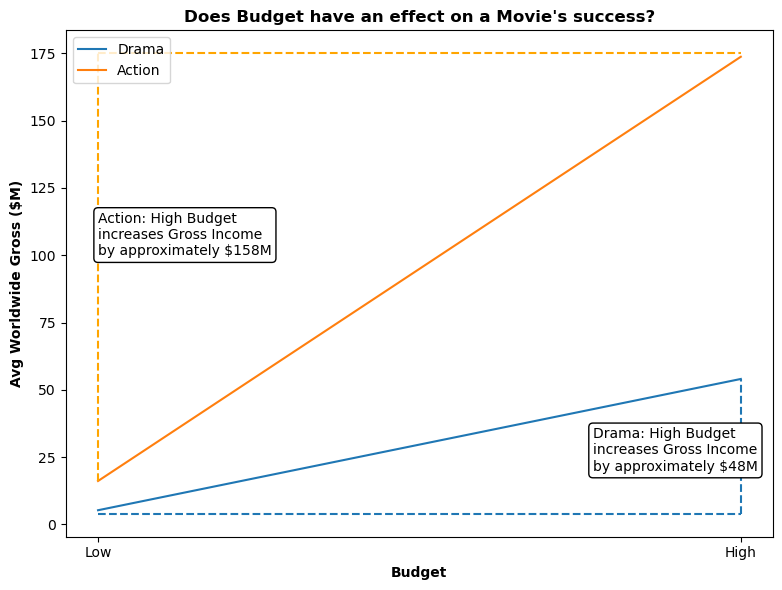

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

x = [0, 1] 
ydrama = [dl/1e6, dh/1e6]
yaction = [al/1e6, ah/1e6]

ax.plot(x, ydrama, label='Drama')
ax.plot(x, yaction, label='Action')
# ax.annotate(('Low', 0), ('High', 50))
ax.hlines(y=4, xmin=0, xmax=1, linestyles='dashed')
ax.vlines(x=1, ymin=4, ymax=54, linestyles='dashed')
ax.text(0.77, 20, 'Drama: High Budget\nincreases Gross Income\nby approximately $48M', bbox=dict(boxstyle='round', fc='white'))
ax.hlines(y=175, xmin=0, xmax=1, linestyles='dashed', color='orange')
ax.vlines(x=0, ymin=16, ymax=175, linestyles='dashed', color='orange')
ax.text(0, 100, 'Action: High Budget\nincreases Gross Income\nby approximately $158M', bbox=dict(boxstyle='round', fc='white'))
plt.xticks([0, 1], ['Low', 'High'])
plt.xlabel('Budget', fontweight='bold')
plt.ylabel('Avg Worldwide Gross ($M)', fontweight='bold')
plt.title('Does Budget have an effect on a Movie\'s success?', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
def getGenre(row):
    if row['isDrama']:
        return 'Drama'
    elif row['isAction']:
        return 'Action'

def getBudget(row):
    if row['isDrama']:
        return row['dramaBudget']
    elif row['isAction']:
        return row['actionBudget']

48250588.42681398 4363425.5
14.89683234484473 15.288767730171184
                      mean       median  count
group                                         
Action, High  2.043219e+08  101635712.0    980
Action, Low   1.841045e+07    3530620.0    791
Drama, High   5.404956e+07   15676373.0   3552
Drama, Low    5.289340e+06     437286.0   3551


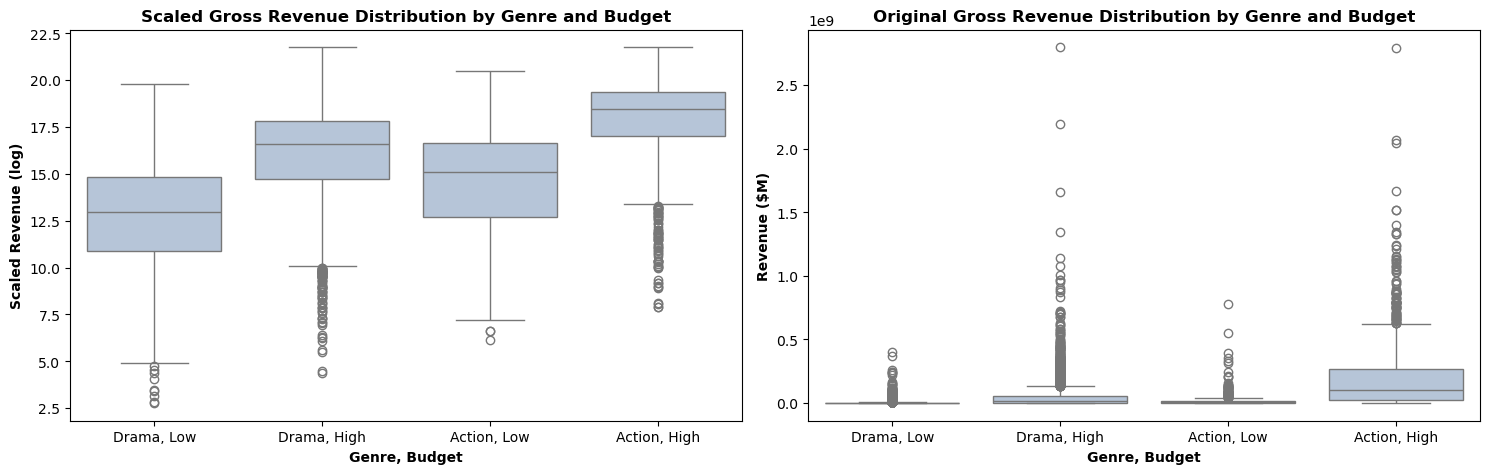

In [8]:
boxplot = pd.DataFrame({
    'genre': df.apply(getGenre, axis=1),
    'budget': df.apply(getBudget, axis=1),
    'revenue': df['worlwide_gross_income'],
    'scaled_revenue': np.log(df['worlwide_gross_income'])})

boxplot['group'] = boxplot['genre'] +', '+ boxplot['budget'].str.capitalize()

print(boxplot['revenue'].mean(), boxplot['revenue'].median())
print(boxplot['scaled_revenue'].mean(), boxplot['scaled_revenue'].median())
print(boxplot.groupby('group')['revenue'].agg(['mean', 'median', 'count']))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
# plt.yscale('log')
sns.boxplot(data=boxplot, x='group', y='scaled_revenue', ax=ax1, color='lightsteelblue')
sns.boxplot(data=boxplot, x='group', y='revenue', ax=ax2, color='lightsteelblue')
ax1.set_title('Scaled Gross Revenue Distribution by Genre and Budget', fontweight='bold')
ax2.set_title('Original Gross Revenue Distribution by Genre and Budget', fontweight='bold')
ax1.set_ylabel('Scaled Revenue (log)', fontweight='bold')
ax1.set_xlabel('Genre, Budget', fontweight='bold')
ax2.set_ylabel('Revenue ($M)', fontweight='bold')
ax2.set_xlabel('Genre, Budget', fontweight='bold')
plt.tight_layout()
plt.show()

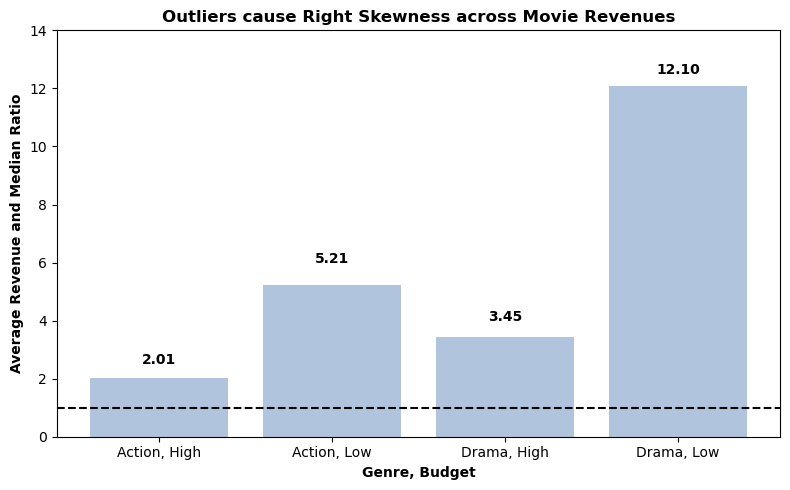

0     2.010336
1     5.214508
2     3.447836
3    12.095836
Name: ratio, dtype: float64


In [9]:
barchart = pd.DataFrame({
    'mean': boxplot.groupby('group')['revenue'].mean(),
    'median': boxplot.groupby('group')['revenue'].median()})

barchart['ratio'] = barchart['mean']/barchart['median']
barchart = barchart.reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(barchart['group'], barchart['ratio'], color='lightsteelblue')
ax.axhline(y=1, color='black', linestyle='dashed')
ax.set_ylabel('Average Revenue and Median Ratio', fontweight='bold')
ax.set_xlabel('Genre, Budget', fontweight='bold')
ax.set_title('Outliers cause Right Skewness across Movie Revenues', fontweight='bold')
ax.set_ylim(0, 14)

ax.text(0, 2.5, '2.01', ha='center', fontweight='bold')
ax.text(1, 6, '5.21', ha='center', fontweight='bold')
ax.text(2, 4, '3.45', ha='center', fontweight='bold')
ax.text(3, 12.5, '12.10', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print(barchart['ratio'])

In [10]:
dataframe = pd.DataFrame({
    'genre': df.apply(getGenre, axis=1),
    'budget': df.apply(getBudget, axis=1),
    'revenue': np.log(df['worlwide_gross_income'])})

model = ols('revenue ~ C(genre) + C(budget) + C(genre):C(budget)', data=dataframe).fit()

anova_result = sm.stats.anova_lm(model, typ=2)
print(anova_result)

                          sum_sq      df            F         PR(>F)
C(genre)             4219.578100     1.0   635.379307  1.825949e-135
C(budget)           23324.107966     1.0  3512.117847   0.000000e+00
C(genre):C(budget)      0.001260     1.0     0.000190   9.890112e-01
Residual            58906.006760  8870.0          NaN            NaN


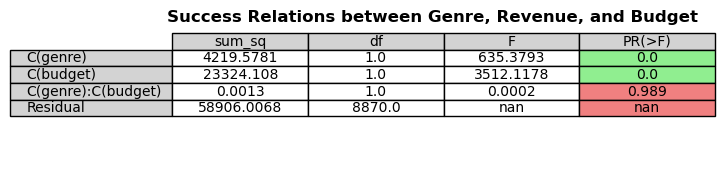

In [11]:
fig, ax = plt.subplots(figsize=(7, 2))
ax.set_axis_off()

mask = ['lightgreen' if p < 0.05 else 'lightcoral' for p in anova_result['PR(>F)']] 
table = ax.table(cellText = anova_result.round(4).values, rowLabels = anova_result.index, colLabels = anova_result.columns,
                 rowColours=['lightgray']*4, colColours=['lightgray']*4, cellLoc ='center', loc ='upper left')        

[table[(i+1, 3)].set_facecolor(c) for i, c in enumerate(mask)]
ax.set_title('Success Relations between Genre, Revenue, and Budget',fontweight ="bold")
plt.show()